In [1]:
import torch
import matplotlib.pyplot as plt
import cv2

from VAE import VAE, vae_loss
from training import *

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from img_dataloader import dataset_imgs

import numpy as np

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
device = "cpu"

In [3]:
vae = VAE(ch = 128, latent_channels = 4).to(device)

dit = DiT(d_model        = 768,
          channels       = 4,
          grid_size      = 32,
          patch_size     = 4,
          timestep_freq  = 128,
          num_freq       = 128,
          num_DiT_blocks = 12,
          num_heads      = 12)

ddpm = DDPM(betas_start = 1e-4, betas_end = 0.02, max_timesteps = 1000, device = device)


In [4]:
vae.load_state_dict(torch.load('vae.pth', map_location = device))
dit.load_state_dict(torch.load('dit.pth', map_location = device))

<All keys matched successfully>

In [5]:
latent_scale = 2.094242572784424

In [ ]:
x = torch.randn(1, 4, 32, 32, device=device)
n = torch.tensor([3.0], dtype=torch.float32, device=device)

for t in tqdm(reversed(range(ddpm.max_timesteps)), total=ddpm.max_timesteps):
    t_batch    = torch.tensor([t], device=device, dtype=torch.long)
    noise_pred = dit(noisy_latent=x, time=t_batch, number=n)
    x          = ddpm.remove_noise(xt=x, t=t, noise=noise_pred)

    # Print every 100 steps
    if t % 100 == 0:
        print(f"t={t:4d}  x.std={x.std().item():.4f}  x.mean={x.mean().item():.4f}")

    if torch.isnan(x).any():
        print(f"NaN at t={t}")
        break

 10%|█         | 102/1000 [00:07<01:18, 11.46it/s]

t= 900  x.std=0.9317  x.mean=0.0295


 20%|██        | 202/1000 [00:20<01:54,  6.96it/s]

t= 800  x.std=0.9669  x.mean=0.0398


 30%|██▉       | 299/1000 [00:48<03:41,  3.16it/s]

...

 40%|████      | 402/1000 [01:37<07:17,  1.37it/s]

t= 600  x.std=1.1045  x.mean=0.0513


 50%|█████     | 502/1000 [02:21<08:31,  1.03s/it]

t= 500  x.std=1.2285  x.mean=0.0644


 56%|█████▌    | 557/1000 [02:36<01:04,  6.92it/s]

In [ ]:
img = sample_from_dit(dit, vae, n_value = 1, scheduler = ddpm, latent_scale = latent_scale, img_size = 256, device = device)
img_np = (img[0].permute(1, 2, 0).clamp(-1, 1).cpu().numpy() + 1) / 2

plt.imshow(img_np)
plt.axis("off")

In [8]:
@torch.no_grad()
def sample_ddim(model, vae, n_value, scheduler, latent_scale,
                steps=50, device='cuda', img_size=256):
    """
    DDIM deterministic sampling - much more stable than DDPM.
    Only needs 50 steps instead of 1000.
    """
    model.eval()
    vae.eval()

    x = torch.randn(1, 4, img_size//8, img_size//8, device=device)
    n = torch.tensor([float(n_value)], device=device)

    # Subsample timesteps: 999, 979, 959, ... 19, 0
    timesteps = list(reversed(range(0, scheduler.max_timesteps, 
                                    scheduler.max_timesteps // steps)))

    for i, t in enumerate(tqdm(timesteps)):
        t_batch = torch.tensor([t], device=device, dtype=torch.long)
        noise_pred = model(noisy_latent=x, time=t_batch, number=n)

        alpha_bar_t = scheduler.alpha_bars_cumprod[t]

        # Predict x0 from noise prediction
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t)
        x0_pred = torch.clamp(x0_pred, -3.0, 3.0)   # same clamp as training

        if i + 1 < len(timesteps):
            t_prev      = timesteps[i + 1]
            alpha_bar_prev = scheduler.alpha_bars_cumprod[t_prev]
        else:
            alpha_bar_prev = torch.tensor(1.0, device=device)

        # DDIM step — fully deterministic, no z noise term
        x = torch.sqrt(alpha_bar_prev) * x0_pred + \
            torch.sqrt(1 - alpha_bar_prev) * noise_pred

    return vae.decode(x * latent_scale)

100%|██████████| 50/50 [00:02<00:00, 19.24it/s]


(-0.5, 255.5, 255.5, -0.5)

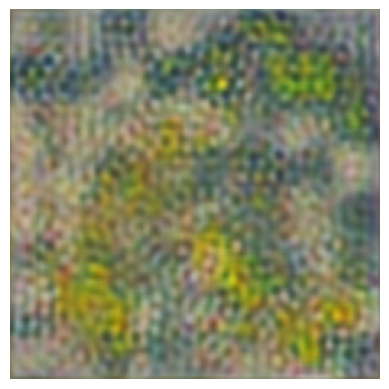

In [11]:
img = sample_ddim(dit, vae, n_value = 10, scheduler = ddpm, latent_scale = latent_scale, img_size = 256, device = device)
img_np = (img[0].permute(1, 2, 0).clamp(-1, 1).cpu().numpy() + 1) / 2

plt.imshow(img_np)
plt.axis("off")

In [ ]:
x = torch.randn(1, 4, 32, 32, device=device)
n = torch.tensor([3.0], dtype=torch.float32, device=device)

prev_std = x.std().item()

for t in reversed(range(ddpm.max_timesteps)):
    t_batch    = torch.tensor([t], device=device, dtype=torch.long)
    noise_pred = dit(noisy_latent=x, time=t_batch, number=n)
    x          = ddpm.remove_noise(xt=x, t=t, noise=noise_pred)

    curr_std = x.std().item()
    
    # Print ONLY when std increases significantly
    if curr_std > prev_std + 0.05:
        print(f"t={t:4d}  std JUMPED {prev_std:.4f} -> {curr_std:.4f}  noise_pred.std={noise_pred.std().item():.4f}")
    
    prev_std = curr_std